# Customer Service Request (311) Analysis — New York City

**Objective:** Analyze NYC 311 service request data, perform data wrangling, identify
patterns, and visualize the major types of complaints across the city.

This notebook follows the task structure of the Customer Service Request Analysis project:
1. Understand the dataset
2. Basic data exploratory analysis (missing values, date handling)
3. Find major types of complaints
4. Visualize complaints by city
5. Compare average response time across complaint types
6. Statistical significance testing (p-values)
7. Kruskal-Wallis H test
8. Observations

## 0. Import Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 150)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline


## 1. Understand the Dataset
### 1.1 Import the dataset

In [39]:
df =pd.read_csv('311_Service_Requests_from_2010_to_Present.csv',low_memory=False)
print("data imported")

data imported


### 1.2Visualize the dataset

In [40]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,Street Name,Cross Street 1,Cross Street 2,Intersection Street 1,Intersection Street 2,Address Type,City,Landmark,Facility Type,Status,Due Date,Resolution Description,Resolution Action Updated Date,Community Board,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Park Facility Name,Park Borough,School Name,School Number,School Region,School Code,School Phone Number,School Address,School City,School State,School Zip,School Not Found,School or Citywide Complaint,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,VERMILYEA AVENUE,ACADEMY STREET,WEST 204 STREET,NaN,NaN,ADDRESS,NEW YORK,NaN,Precinct,Closed,01/01/2016 07:59:45 AM,The Police Department responded and upon arriv...,01/01/2016 12:55:15 AM,12 MANHATTAN,MANHATTAN,1005409.0,254678.0,Unspecified,MANHATTAN,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,23 AVENUE,27 STREET,28 STREET,NaN,NaN,ADDRESS,ASTORIA,NaN,Precinct,Closed,01/01/2016 07:59:44 AM,The Police Department responded to the complai...,01/01/2016 01:26:57 AM,01 QUEENS,QUEENS,1007766.0,221986.0,Unspecified,QUEENS,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,VALENTINE AVENUE,EAST 198 STREET,EAST 199 STREET,NaN,NaN,ADDRESS,BRONX,NaN,Precinct,Closed,01/01/2016 07:59:29 AM,The Police Department responded and upon arriv...,01/01/2016 04:51:03 AM,07 BRONX,BRONX,1015081.0,256380.0,Unspecified,BRONX,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,BAISLEY AVENUE,EDISON AVENUE,B STREET,NaN,NaN,ADDRESS,BRONX,NaN,Precinct,Closed,01/01/2016 07:57:46 AM,The Police Department responded to the complai...,01/01/2016 07:43:13 AM,10 BRONX,BRONX,1031740.0,243899.0,Unspecified,BRONX,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,57 ROAD,SEABURY STREET,HOFFMAN DRIVE,NaN,NaN,ADDRESS,ELMHURST,NaN,Precinct,Closed,01/01/2016 07:56:58 AM,The Police Department responded and upon arriv...,01/01/2016 03:24:42 AM,04 QUEENS,QUEENS,1019123.0,206375.0,Unspecified,QUEENS,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [41]:
df.tail()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,Street Name,Cross Street 1,Cross Street 2,Intersection Street 1,Intersection Street 2,Address Type,City,Landmark,Facility Type,Status,Due Date,Resolution Description,Resolution Action Updated Date,Community Board,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Park Facility Name,Park Borough,School Name,School Number,School Region,School Code,School Phone Number,School Address,School City,School State,School Zip,School Not Found,School or Citywide Complaint,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
364553,29609918,01/01/2015 12:04:44 AM,01/01/2015 10:22:31 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Hydrant,Street/Sidewalk,11421.0,84-25 85 ROAD,85 ROAD,FOREST PARKWAY,85 STREET,NaN,NaN,ADDRESS,WOODHAVEN,NaN,Precinct,Closed,01/01/2015 08:04:44 AM,The Police Department responded to the complai...,01/01/2015 10:22:31 AM,09 QUEENS,QUEENS,1022809.0,192567.0,Unspecified,QUEENS,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.695145,-73.860949,"(40.69514470265117, -73.86094888534394)"
364554,29608392,01/01/2015 12:04:28 AM,01/01/2015 02:25:02 AM,NYPD,New York City Police Department,Noise - Vehicle,Car/Truck Horn,Street/Sidewalk,10468.0,2555 SEDGWICK AVENUE,SEDGWICK AVENUE,BAILEY AVENUE,BEND,NaN,NaN,ADDRESS,BRONX,NaN,Precinct,Closed,01/01/2015 08:04:28 AM,The Police Department responded to the complai...,01/01/2015 02:25:02 AM,07 BRONX,BRONX,1009923.0,255465.0,Unspecified,BRONX,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.867830,-73.907178,"(40.86782963689454, -73.90717786644662)"
364555,29607589,01/01/2015 12:01:30 AM,01/01/2015 12:20:33 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10031.0,508 WEST 139 STREET,WEST 139 STREET,AMSTERDAM AVENUE,HAMILTON PLACE,NaN,NaN,ADDRESS,NEW YORK,NaN,Precinct,Closed,01/01/2015 08:01:30 AM,The Police Department responded to the complai...,01/01/2015 12:20:33 AM,09 MANHATTAN,MANHATTAN,997847.0,238629.0,Unspecified,MANHATTAN,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.821647,-73.950873,"(40.821646626438095, -73.95087342885292)"
364556,29610889,01/01/2015 12:01:29 AM,01/01/2015 02:42:22 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10466.0,931 EAST 226 STREET,EAST 226 STREET,BRONXWOOD AVENUE,PAULDING AVENUE,NaN,NaN,ADDRESS,BRONX,NaN,Precinct,Closed,01/01/2015 08:01:29 AM,The Police Department responded and upon arriv...,01/01/2015 02:42:22 AM,12 BRONX,BRONX,1024816.0,262237.0,Unspecified,BRONX,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.886361,-73.853290,"(40.88636077906953, -73.85329048666742)"
364557,29611816,01/01/2015 12:00:50 AM,01/01/2015 02:47:50 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11420.0,123-19 135 STREET,135 STREET,ROCKAWAY BOULEVARD,SUTTER AVENUE,NaN,NaN,ADDRESS,SOUTH OZONE PARK,NaN,Precinct,Closed,01/01/2015 08:00:50 AM,The Police Department responded to the complai...,01/01/2015 02:47:50 AM,10 QUEENS,QUEENS,1038733.0,184971.0,Unspecified,QUEENS,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.674212,-73.803585,"(40.674211762243935, -73.80358548685278)"


### 1.3 Print the columns of the DataFrame

In [42]:
print(df.columns.tolist())

['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2', 'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date', 'Community Board', 'Borough', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough', 'School Name', 'School Number', 'School Region', 'School Code', 'School Phone Number', 'School Address', 'School City', 'School State', 'School Zip', 'School Not Found', 'School or Citywide Complaint', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Garage Lot Name', 'Ferry Direction', 'Ferry Terminal Name', 'Latitude', 'Longitude', 'Location']


### 1.4 Identify the shape of the dataset

In [43]:
print("shape of the dataseset (rows,columns):",df.shape)

shape of the dataseset (rows,columns): (364558, 53)


### 1.5 Identify the variables with null values

In [44]:
null_counts =df.isnull().sum()
null_counts = null_counts[null_counts >0].sort_values(ascending=False)
print("columns with null values\n")
print(null_counts)

columns with null values

School or Citywide Complaint      364558
Taxi Pick Up Location             364558
Taxi Company Borough              364558
Vehicle Type                      364558
Garage Lot Name                   364558
Ferry Direction                   364557
Ferry Terminal Name               364556
Road Ramp                         364296
Bridge Highway Segment            364296
Bridge Highway Direction          364261
Bridge Highway Name               364261
Landmark                          364183
Intersection Street 2             314046
Intersection Street 1             313438
Cross Street 2                     57805
Cross Street 1                     57188
Incident Address                   51699
Street Name                        51699
Descriptor                          6501
Longitude                           4030
Location                            4030
X Coordinate (State Plane)          4030
Latitude                            4030
Y Coordinate (State Plane)     

## 2. Perform basic data exploratory analysis:
### 2.1 Draw a frequency plot to show the number of null values in each column of the DataFrame

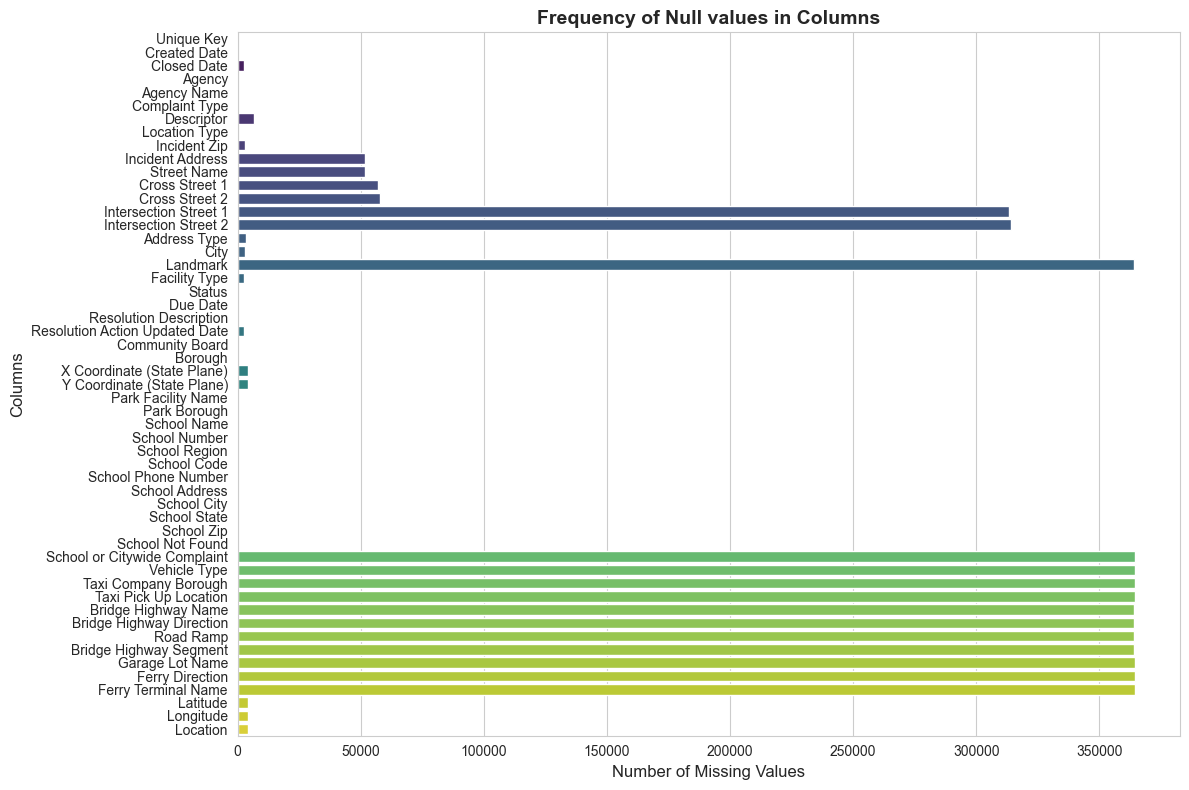

In [45]:
null_count_all =df.isnull().sum()

plt.figure(figsize =(12,8))
sns.barplot(
    x = null_count_all.values,
    y = null_count_all.index,
    hue=null_count_all.index,  
    palette="viridis",
    legend=False
)
plt.title("Frequency of Null values in Columns",fontsize =14, fontweight ="bold")
plt.xlabel("Number of Missing Values", fontsize=12)
plt.ylabel("Columns", fontsize=12)
plt.tight_layout()
plt.show()

### 2.2Missing value treatment
 #### cheking the percetage of null values 

In [46]:
df.isnull().sum()/ len(df)*100

Unique Key                          0.000000
Created Date                        0.000000
Closed Date                         0.653120
Agency                              0.000000
Agency Name                         0.000000
Complaint Type                      0.000000
Descriptor                          1.783255
Location Type                       0.036483
Incident Zip                        0.822366
Incident Address                   14.181283
Street Name                        14.181283
Cross Street 1                     15.686941
Cross Street 2                     15.856187
Intersection Street 1              85.977540
Intersection Street 2              86.144317
Address Type                        0.892039
City                                0.822091
Landmark                           99.897136
Facility Type                       0.655314
Status                              0.000000
Due Date                            0.000823
Resolution Description              0.000000
Resolution

<h3> we will remove the columns more than 60 %

In [47]:
threshold = len(df) * 0.6
df.dropna(thresh=threshold, axis=1, inplace=True)

### 2.2.1 Remove the records whose Closed Date values are null
Records with no `Closed Date` represent requests that were never closed, so the
"time to close" metric is undefined for them. We drop these rows.


In [48]:
print("Number of rows before dropping null Closed Date:",df.shape[0])
df = df[df['Closed Date'].notnull()].copy()
print("Number of rows after dropping null Closed Date:",df.shape[0])

Number of rows before dropping null Closed Date: 364558
Number of rows after dropping null Closed Date: 362177


### 2.3 Analyze the date column, and remove entries with an incorrect timeline

First convert `Created Date` and `Closed Date` to proper datetime objects, then remove
any rows where the `Closed Date` is earlier than the `Created Date` (a logical impossibility).

In [49]:
df['Created Date'] = pd.to_datetime(df['Created Date'], format='%m/%d/%Y %I:%M:%S %p')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], format='%m/%d/%Y %I:%M:%S %p')

print("Rows before removing incorrect timelines:", df.shape[0])
df = df[df['Closed Date'] >= df['Created Date']].copy()
print("Rows after removing incorrect timelines:", df.shape[0])


Rows before removing incorrect timelines: 362177
Rows after removing incorrect timelines: 362177


#### 2.3.1 Calculate the time elapsed between Closed Date and Created Date

In [50]:
df["Request_Closing_Time"] =df["Closed Date"]- df["Created Date"]
df[['Created Date', 'Closed Date', 'Request_Closing_Time']].head()

,Created Date,Closed Date,Request_Closing_Time
0,2015-12-31 23:59:45,2016-01-01 00:55:15,0 days 00:55:30
1,2015-12-31 23:59:44,2016-01-01 01:26:57,0 days 01:27:13
2,2015-12-31 23:59:29,2016-01-01 04:51:03,0 days 04:51:34
3,2015-12-31 23:57:46,2016-01-01 07:43:13,0 days 07:45:27
4,2015-12-31 23:56:58,2016-01-01 03:24:42,0 days 03:27:44


#### 2.3.2 Convert the calculated date to seconds for a better representation

In [51]:
df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()
df[['Created Date', 'Closed Date', 'Request_Closing_Time']].head()


,Created Date,Closed Date,Request_Closing_Time
0,2015-12-31 23:59:45,2016-01-01 00:55:15,3330.0
1,2015-12-31 23:59:44,2016-01-01 01:26:57,5233.0
2,2015-12-31 23:59:29,2016-01-01 04:51:03,17494.0
3,2015-12-31 23:57:46,2016-01-01 07:43:13,27927.0
4,2015-12-31 23:56:58,2016-01-01 03:24:42,12464.0


#### 2.3.3 View the descriptive statistics for the newly created column

In [52]:
df["Request_Closing_Time"].describe()

count    3.621770e+05
mean     1.511330e+04
std      2.110255e+04
min      6.100000e+01
25%      4.533000e+03
50%      9.616000e+03
75%      1.887800e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

#### 2.3.4 Check the number of null values in the Complaint_Type and City columns

In [53]:
print("Null values in complaint_type column:",df['Complaint Type'].isnull().sum())
print("Null values in City column:",df['City'].isnull().sum())

Null values in complaint_type column: 0
Null values in City column: 674


#### 2.3.5 Impute the NA value with 'Unknown City'

In [54]:
df['City'] = df['City'].fillna('Unknown City')
print("Null values in 'City' after imputation:", df['City'].isnull().sum())

Null values in 'City' after imputation: 0


#### 2.3.6 Draw a frequency plot for the complaints in each city

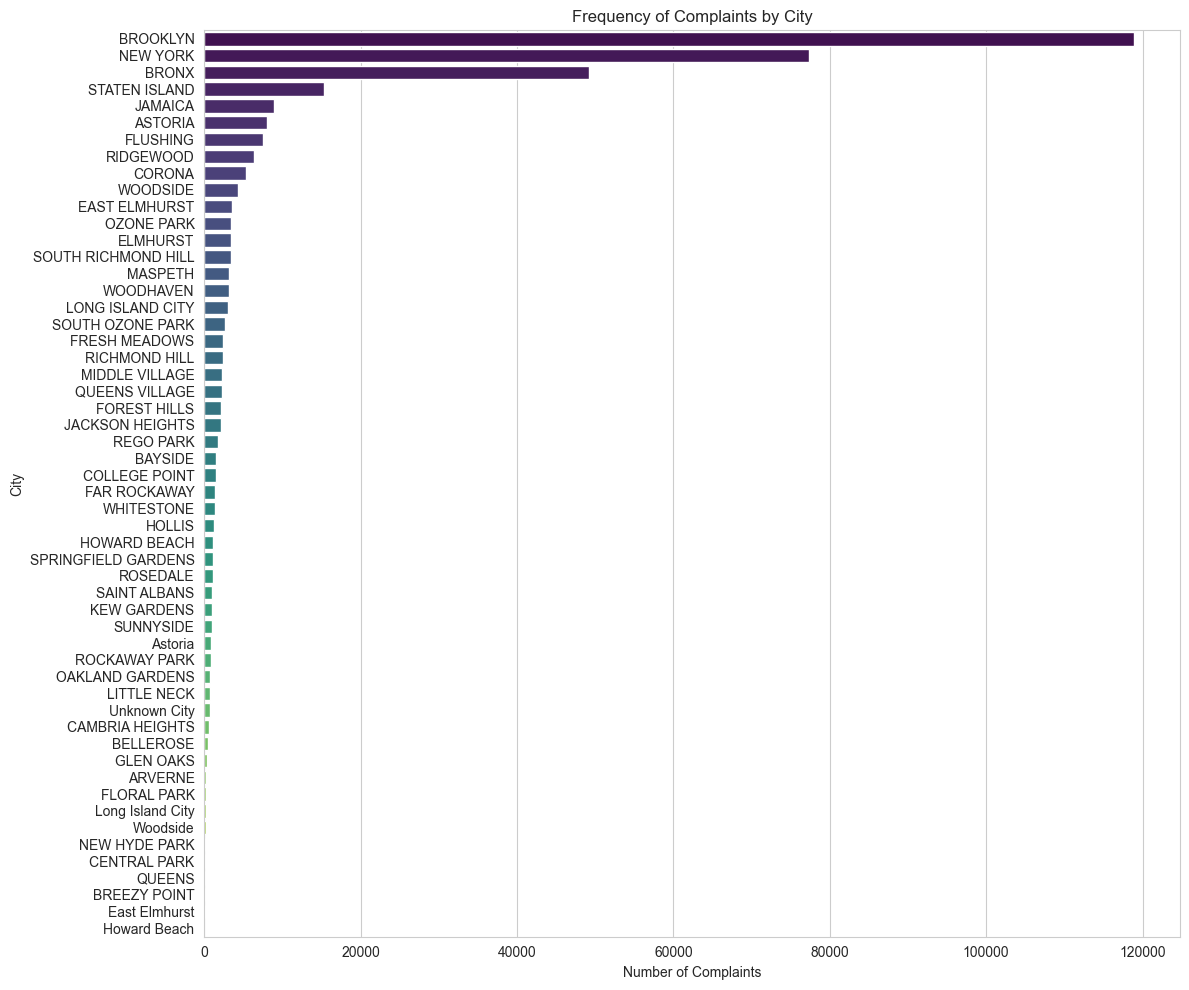

In [55]:
plt.figure(figsize=(12, 10))
city_counts = df['City'].value_counts()
sns.barplot(x=city_counts.values, y=city_counts.index, hue=city_counts.index,
            palette='viridis', legend=False)
plt.xlabel('Number of Complaints')
plt.ylabel('City')
plt.title('Frequency of Complaints by City')
plt.tight_layout()
plt.show()

#### 2.3.7 Create a scatter and hexbin plot of the concentration of complaints across Brooklyn

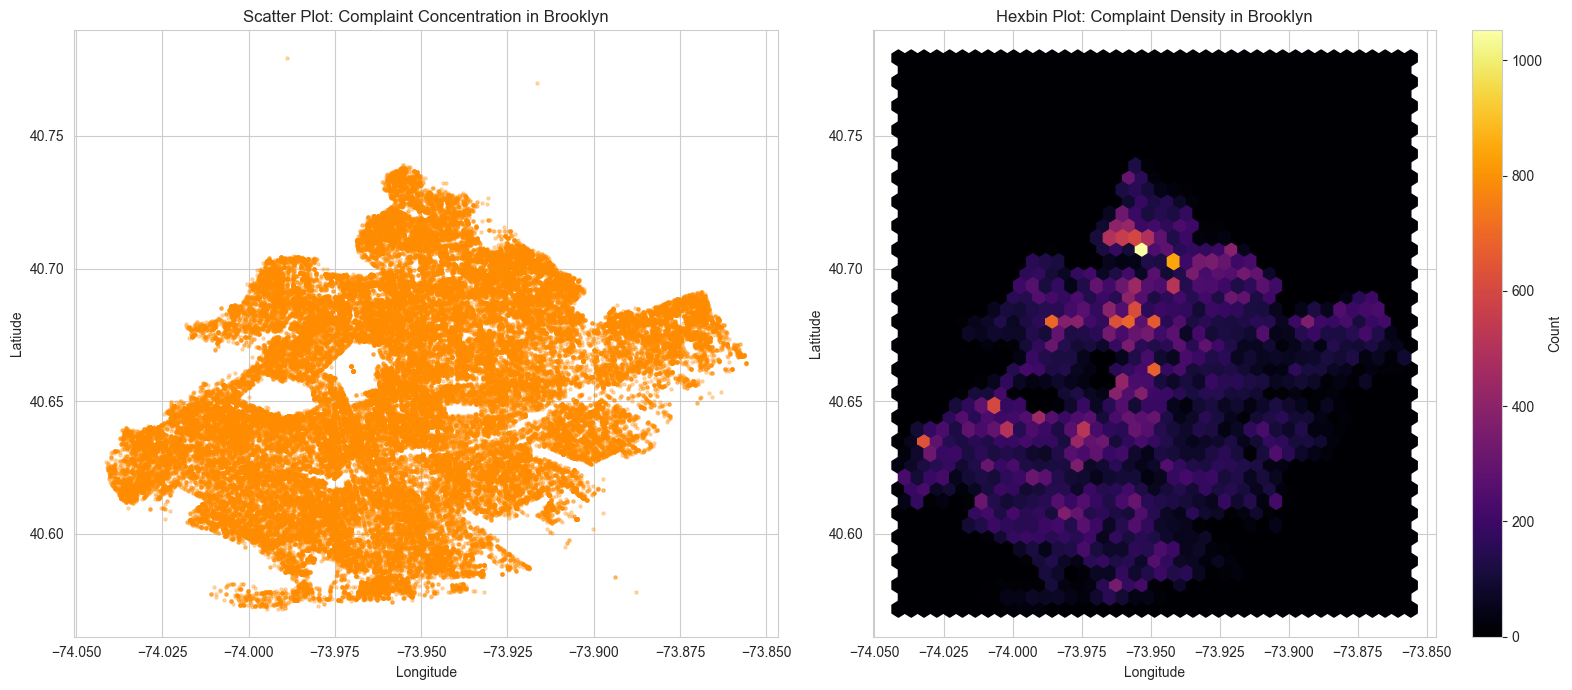

In [56]:
brooklyn =df[df['City']=='BROOKLYN'].dropna(subset=['Longitude','Latitude'])
fig, axes =plt.subplots(1,2, figsize=(16,7))

# Scatter plot
axes[0].scatter(brooklyn['Longitude'],brooklyn['Latitude'],alpha =0.3,s=5,color ='darkorange')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latiude')
axes[0].set_title("Scatter Plot: Complaint Concentration in Brooklyn")

# Hexbin plot
hb = axes[1].hexbin(brooklyn['Longitude'], brooklyn['Latitude'], gridsize=40, cmap='inferno')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Hexbin Plot: Complaint Density in Brooklyn')
fig.colorbar(hb, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

## 3. Find Major Types of Complaints
### 3.1 Plot a bar graph to show the types of complaints

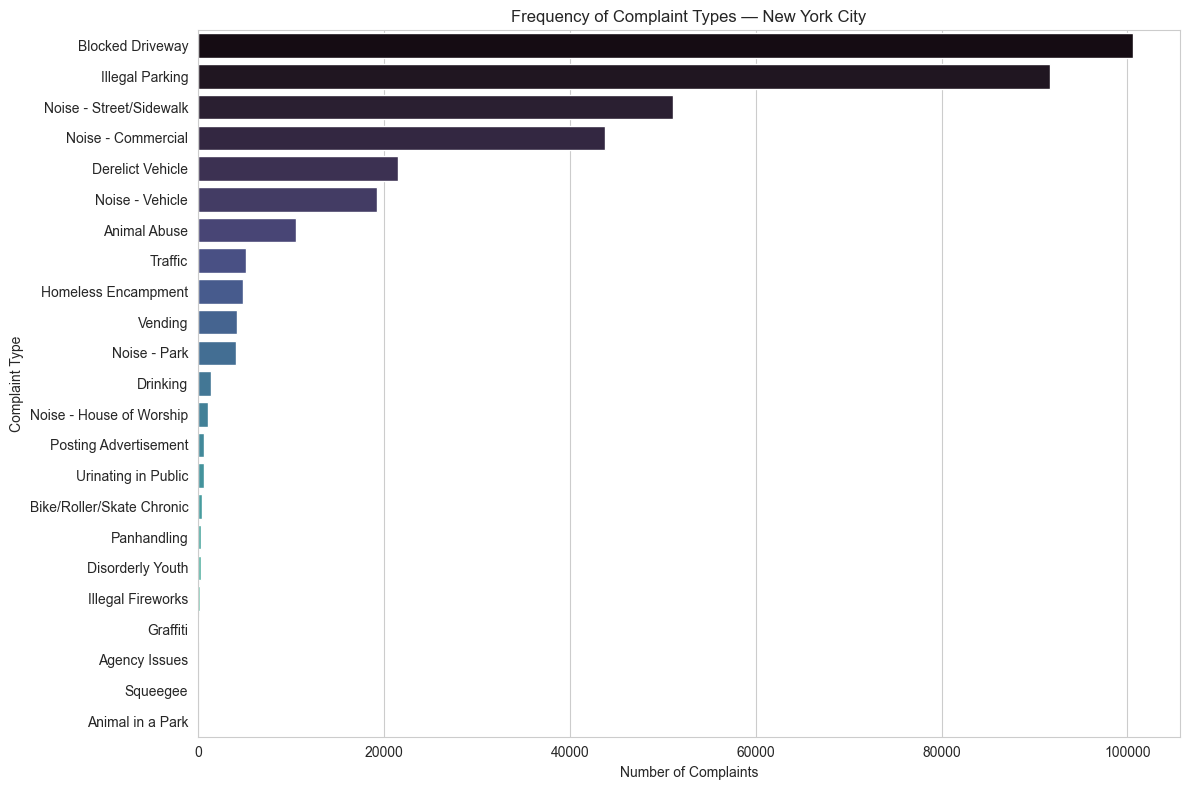

In [57]:
plt.figure(figsize=(12, 8))
complaint_counts = df['Complaint Type'].value_counts()
sns.barplot(x=complaint_counts.values, y=complaint_counts.index, hue=complaint_counts.index,
            palette='mako', legend=False)
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.title('Frequency of Complaint Types — New York City')
plt.tight_layout()
plt.show()


### 3.2 Check the frequency of various types of complaints for New York City

In [58]:
nyc_complaints = df[df['City'] == 'NEW YORK']['Complaint Type'].value_counts()
print("Complaint type frequency for City = 'NEW YORK':\n")
print(nyc_complaints)

Complaint type frequency for City = 'NEW YORK':

Complaint Type
Noise - Street/Sidewalk      22245
Noise - Commercial           18686
Illegal Parking              14549
Noise - Vehicle               6294
Homeless Encampment           3060
Blocked Driveway              2705
Vending                       2638
Animal Abuse                  1941
Traffic                       1769
Noise - Park                  1243
Derelict Vehicle               695
Drinking                       321
Urinating in Public            264
Bike/Roller/Skate Chronic      254
Noise - House of Worship       222
Panhandling                    206
Disorderly Youth                81
Posting Advertisement           49
Illegal Fireworks               38
Graffiti                        25
Squeegee                         4
Name: count, dtype: int64


### 3.3 Find the top 10 complaint types

In [59]:
top10_complaints = df['Complaint Type'].value_counts().head(10)
print("top 10 complaintes in :\n")
print(top10_complaints)

top 10 complaintes in :

Complaint Type
Blocked Driveway           100624
Illegal Parking             91716
Noise - Street/Sidewalk     51139
Noise - Commercial          43751
Derelict Vehicle            21518
Noise - Vehicle             19301
Animal Abuse                10530
Traffic                      5196
Homeless Encampment          4879
Vending                      4185
Name: count, dtype: int64


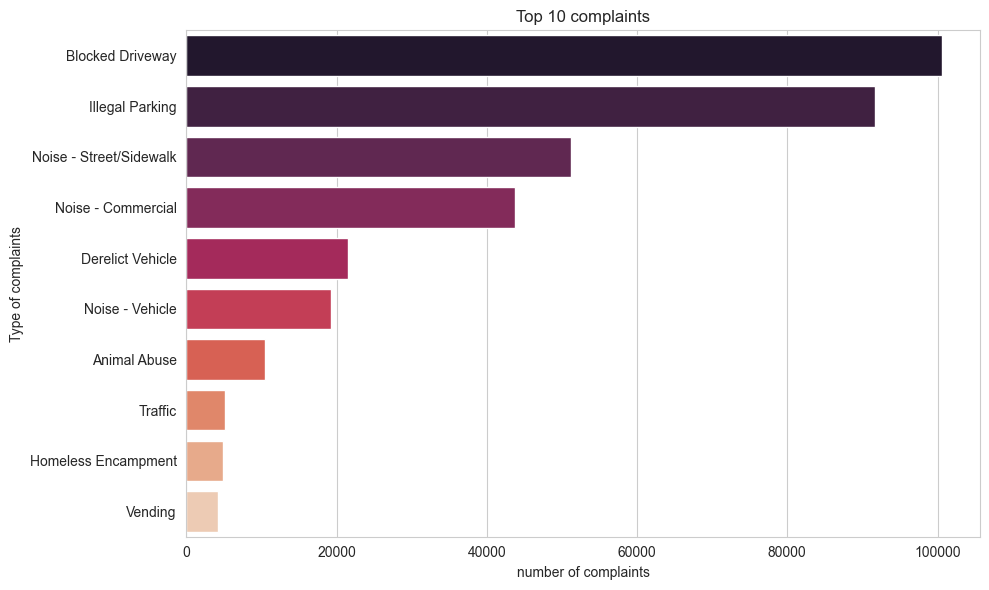

In [60]:
plt.figure(figsize=(10,6))
sns.barplot(x =top10_complaints.values, y =top10_complaints.index,hue =top10_complaints.index,palette ='rocket',legend =False)
plt.xlabel("number of complaints")
plt.ylabel("Type of complaints")
plt.title("Top 10 complaints")
plt.tight_layout()
plt.show()

### 3.4 Display the various types of complaints in each city

In [61]:
complaints_by_city = df.groupby('City')['Complaint Type'].value_counts()
print(complaints_by_city)

City      Complaint Type         
ARVERNE   Illegal Parking             62
          Blocked Driveway            50
          Animal Abuse                46
          Derelict Vehicle            32
          Noise - Street/Sidewalk     29
                                    ... 
Woodside  Illegal Parking            124
          Blocked Driveway            27
          Derelict Vehicle             8
          Noise - Street/Sidewalk      5
          Noise - Commercial           2
Name: count, Length: 792, dtype: int64


### 3.5 Create a DataFrame, df_new, with cities as columns and complaint types as rows

In [62]:
df_new = pd.crosstab(df['Complaint Type'], df['City'])
print("Shape of df_new:", df_new.shape)
df_new.head(10)

Shape of df_new: (23, 54)


City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,COLLEGE POINT,CORONA,EAST ELMHURST,ELMHURST,East Elmhurst,FAR ROCKAWAY,FLORAL PARK,FLUSHING,FOREST HILLS,FRESH MEADOWS,GLEN OAKS,HOLLIS,HOWARD BEACH,Howard Beach,JACKSON HEIGHTS,JAMAICA,KEW GARDENS,LITTLE NECK,LONG ISLAND CITY,Long Island City,MASPETH,MIDDLE VILLAGE,NEW HYDE PARK,NEW YORK,OAKLAND GARDENS,OZONE PARK,QUEENS,QUEENS VILLAGE,REGO PARK,RICHMOND HILL,RIDGEWOOD,ROCKAWAY PARK,ROSEDALE,SAINT ALBANS,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,Unknown City,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Agency Issues,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0,0,0
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,35,104,85,59,0,111,7,191,78,66,5,39,51,0,50,317,26,21,40,0,56,36,1,1941,29,72,1,90,33,55,154,33,44,43,74,40,42,786,40,1,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,0,0,1,2,0,0,0,3,6,0,0,0,1,0,2,3,0,0,3,0,1,1,0,254,2,1,0,0,0,0,3,0,2,0,1,1,0,10,2,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,597,3597,1925,1992,0,383,33,3640,873,682,48,442,215,1,703,3620,429,174,1052,55,1000,663,76,2705,177,1681,3,772,780,1099,2161,80,270,318,1202,1946,330,2845,278,86,279,1363,2038,27
Derelict Vehicle,32,426,14,231,120,3,2402,6257,148,0,223,72,136,94,2,215,74,532,71,347,57,162,172,0,41,1132,16,73,220,4,510,366,14,695,117,479,2,478,94,200,507,19,247,248,425,356,267,2184,17,63,279,369,298,8
Disorderly Youth,2,5,0,2,2,0,66,79,0,0,1,6,1,2,0,1,1,2,1,0,0,1,1,0,0,9,0,2,2,0,2,0,0,81,1,4,0,0,0,0,3,4,0,1,2,2,0,25,2,0,1,0,1,0
Drinking,1,43,0,1,1,1,206,291,0,0,1,34,9,13,0,4,1,47,1,2,0,3,4,0,10,40,1,1,8,0,9,2,0,321,2,20,0,5,4,10,10,23,2,3,14,25,6,188,12,3,3,4,15,0
Graffiti,1,4,0,3,0,0,15,60,0,0,2,4,3,1,0,0,0,6,3,0,0,0,0,0,1,3,0,0,3,0,1,0,0,25,0,0,0,1,1,1,3,0,2,0,2,0,0,6,1,0,1,0,4,0


## 4. Visualize the Major Types of Complaints in Each City

### 4.1 Stacked bar chart — complaint types across cities (single chart, multi-color)

To keep the chart readable, we focus on the top 10 cities by complaint volume and the
top 8 complaint types; everything else is grouped into an "Other" category.


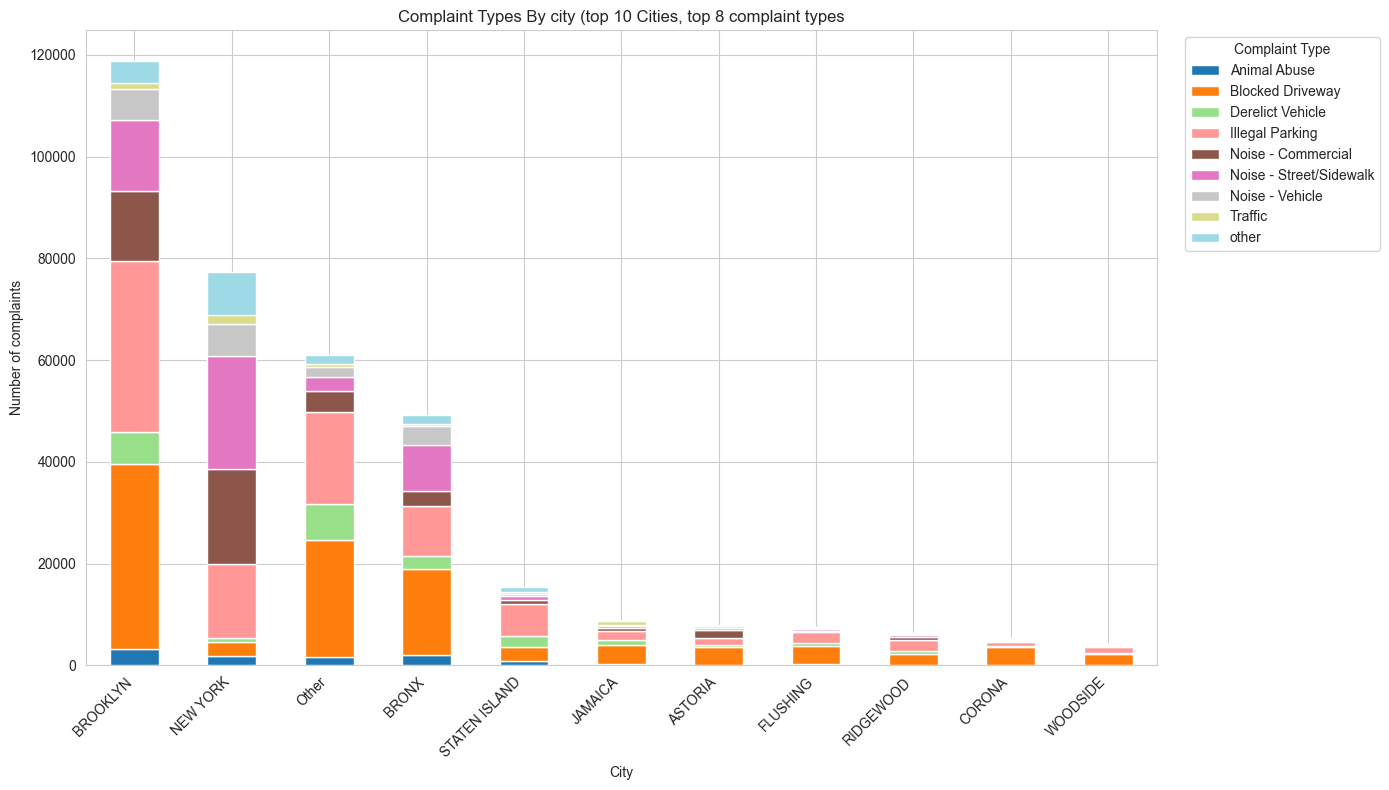

In [63]:
top_cities = df['City'].value_counts().head(10).index
top_types =df['Complaint Type'].value_counts().head(8).index

plot_df =df.copy()
plot_df['City_grp'] = plot_df['City'].where(plot_df['City'].isin(top_cities),'Other')
plot_df['Type_grp'] = plot_df['Complaint Type'].where(plot_df['Complaint Type'].isin(top_types),'other')

pivot =pd.crosstab(plot_df['City_grp'],plot_df['Type_grp'])
pivot =pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

pivot.plot(kind='bar',stacked=True,figsize=(14,8),colormap='tab20')
plt.xlabel('City')
plt.ylabel('Number of complaints')
plt.title('Complaint Types By city (top 10 Cities, top 8 complaint types')
plt.legend(title ='Complaint Type',bbox_to_anchor=(1.02,1),loc ='upper left')
plt.xticks(rotation=45, ha ='right')
plt.tight_layout()
plt.show()

### 4.2 Sort complaint types by average Request_Closing_Time, grouped by location (City)

In [64]:
avg_closing_by_type_city = (
    df.groupby(['City','Complaint Type'])['Request_Closing_Time']
    .mean()
    .reset_index()
    .sort_values('Request_Closing_Time',ascending =False)          
)
avg_closing_by_type_city.head(20)

,City,Complaint Type,Request_Closing_Time
510,QUEENS,Animal in a Park,1.212634e+06
525,QUEENS VILLAGE,Graffiti,1.919950e+05
63,BELLEROSE,Homeless Encampment,1.409300e+05
653,SOUTH RICHMOND HILL,Bike/Roller/Skate Chronic,1.112770e+05
482,OAKLAND GARDENS,Homeless Encampment,1.031560e+05
682,SPRINGFIELD GARDENS,Posting Advertisement,7.021050e+04
126,CAMBRIA HEIGHTS,Homeless Encampment,7.010983e+04
609,ROSEDALE,Homeless Encampment,6.789875e+04
438,MIDDLE VILLAGE,Bike/Roller/Skate Chronic,5.645600e+04
60,BELLEROSE,Derelict Vehicle,5.524688e+04


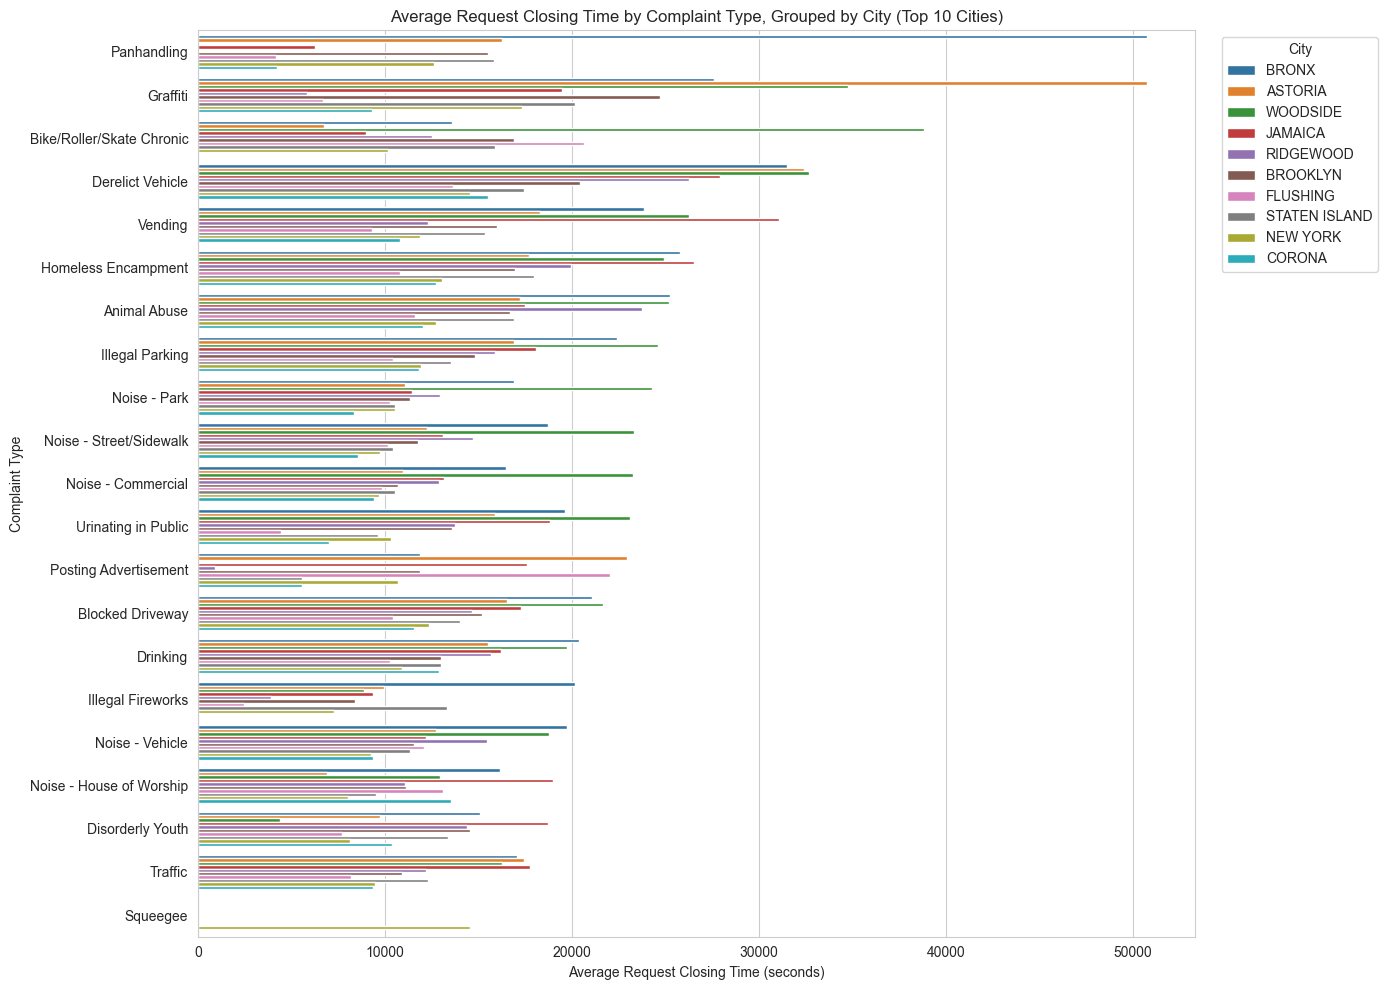

In [65]:
# Visualize for the top 10 cities by volume
top_city_data = avg_closing_by_type_city[avg_closing_by_type_city['City'].isin(top_cities)]

plt.figure(figsize=(14, 10))
sns.barplot(
    data=top_city_data,
    x='Request_Closing_Time', y='Complaint Type', hue='City'
)
plt.xlabel('Average Request Closing Time (seconds)')
plt.ylabel('Complaint Type')
plt.title('Average Request Closing Time by Complaint Type, Grouped by City (Top 10 Cities)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='City')
plt.tight_layout()
plt.show()


## 5. Average Response Time Across Different Complaint Types (Overall)
### 5.1 Visualize the average of Request_Closing_Time

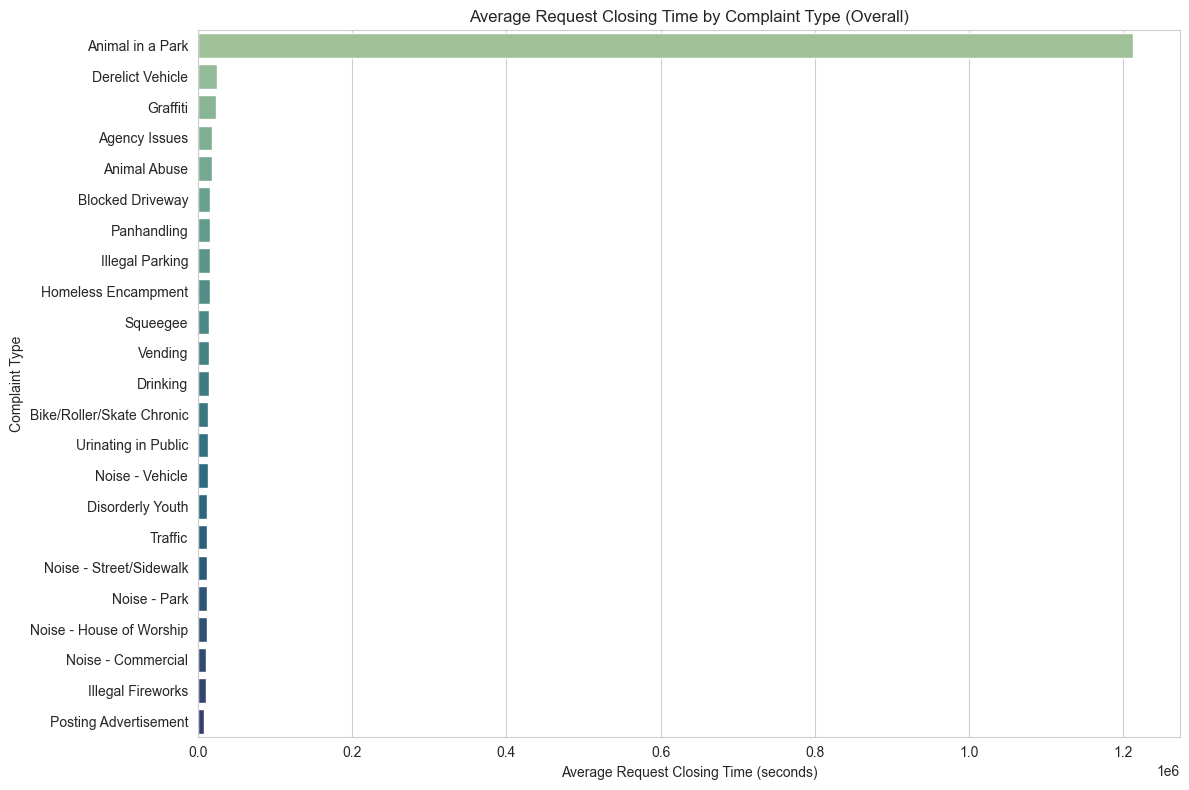

In [67]:
avg_closing_overall = (
    df.groupby('Complaint Type')['Request_Closing_Time']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))
sns.barplot(x=avg_closing_overall.values, y=avg_closing_overall.index,
            hue=avg_closing_overall.index, palette='crest', legend=False)
plt.xlabel('Average Request Closing Time (seconds)')
plt.ylabel('Complaint Type')
plt.title('Average Request Closing Time by Complaint Type (Overall)')
plt.tight_layout()
plt.show()



print(avg_closing_overall)


Observation: The average response (closing) time clearly differs across complaint types — e.g., complaints like Animal Abuse or Homeless Encampment tend to take much longer to resolve than Noise or Blocked Driveway complaints, which are typically handled faster by NYPD precincts. This suggests response time is not uniform across complaint types — something we test formally below.

## 6. Identify Significant Variables Using Statistical Analysis (p-values)

**Hypotheses:**
- **H0 (Null Hypothesis):** The average response time (`Request_Closing_Time`) is the
  same across all complaint types.
- **H1 (Alternative Hypothesis):** The average response time is **not** the same across
  all complaint types — i.e., `Complaint Type` is a significant variable affecting
  `Request_Closing_Time`.

We test this using a one-way ANOVA first (parametric test), then confirm with the
Kruskal-Wallis H test (non-parametric, since response-time data is unlikely to be
normally distributed — it is heavily right-skewed)

In [70]:
# Build groups: response time (in seconds) for each complaint type
groups = [
    df.loc[df['Complaint Type'] == ctype, 'Request_Closing_Time'].dropna()
    for ctype in df['Complaint Type'].unique()
]

# One-way ANOVA
f_stat, p_value_anova = stats.f_oneway(*groups)
print("One-way ANOVA results:")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value     = {p_value_anova:.4e}")

alpha = 0.05
if p_value_anova < alpha:
    print(f"\nSince p-value < {alpha}, we reject H0.")
    print("Complaint Type has a statistically significant effect on Request_Closing_Time.")
else:
    print(f"\nSince p-value >= {alpha}, we fail to reject H0.")
    print("No statistically significant effect of Complaint Type on Request_Closing_Time.")

One-way ANOVA results:
F-statistic = 565.2616
p-value     = 0.0000e+00

Since p-value < 0.05, we reject H0.
Complaint Type has a statistically significant effect on Request_Closing_Time.


## 7. Perform a Kruskal-Wallis H Test

The Kruskal-Wallis H test is the non-parametric counterpart of one-way ANOVA. It does
not assume normally distributed data, which makes it more appropriate here since
`Request_Closing_Time` is heavily right-skewed (many quick resolutions, a long tail of
slow ones).

- **H0:** All sample distributions of `Request_Closing_Time` are equal across complaint types.
- **H1:** At least one sample distribution differs from the others.


In [71]:
h_stat, p_value_kw = stats.kruskal(*groups)
print("Kruskal-Wallis H test results:")
print(f"H-statistic = {h_stat:.4f}")
print(f"p-value     = {p_value_kw:.4e}")


Kruskal-Wallis H test results:
H-statistic = 11988.2694
p-value     = 0.0000e+00


### 7.1 Fail to reject H0: All sample distributions are equal

### 7.2 Reject H0: One or more sample distributions are not equal

In [72]:
alpha = 0.05
if p_value_kw < alpha:
    print(f"p-value ({p_value_kw:.4e}) < alpha ({alpha})")
    print("=> REJECT H0: One or more sample distributions of Request_Closing_Time")
    print("   are NOT equal across complaint types.")
    print("=> Complaint Type IS a significant factor affecting response time.")
else:
    print(f"p-value ({p_value_kw:.4e}) >= alpha ({alpha})")
    print("=> FAIL TO REJECT H0: All sample distributions of Request_Closing_Time")
    print("   are statistically equal across complaint types.")


p-value (0.0000e+00) < alpha (0.05)
=> REJECT H0: One or more sample distributions of Request_Closing_Time
   are NOT equal across complaint types.
=> Complaint Type IS a significant factor affecting response time.


# Observations


## 1. Dataset & Structure

- The dataset is sourced from **NYC 311 service requests (2010 to present)** and contains a large number of rows and up to **60+ columns**.
- Many columns have significant missing data, and those exceeding **60% null values** are dropped to keep the dataset usable.
- Remaining null values in the `City` column are imputed with `'Unknown City'` to preserve those records for analysis.

## 2. Data Quality & Cleaning

- Records with **no `Closed Date`** are removed since "time to close" cannot be computed for unresolved requests.
- Rows where **`Closed Date` is earlier than `Created Date`** (logically impossible) are also filtered out.
- A new feature, **`Request_Closing_Time`**, is calculated as the difference between `Closed Date` and `Created Date`, then converted to **seconds** for uniform numeric analysis.

## 3. Complaint Patterns

- **BROOKLYN** emerges as a high-volume city — scatter and hexbin plots reveal geographic clustering of complaints, with certain neighborhoods having particularly dense complaint activity.
- The analysis identifies **top 10 complaint types** across the city. Common high-frequency types include noise, blocked driveways, and similar urban issues typically handled quickly by NYPD.
- A cross-tabulation (`df_new`) maps complaint types against cities, revealing which complaint categories dominate in each borough/city.

## 4. Response Time Findings

- Average `Request_Closing_Time` varies significantly by complaint type:
  - **Slower to resolve:** Animal Abuse, Homeless Encampment — these involve multiple agencies and longer coordination.
  - **Faster to resolve:** Noise, Blocked Driveway — typically handled at the precinct level.
- This non-uniform distribution in response time suggests `Complaint Type` is a meaningful predictor of how long a request takes to close.

## 5. Statistical Testing

### One-Way ANOVA
- Tests whether average response time is equal across all complaint types.
- If the **p-value < 0.05**, H₀ is rejected — meaning complaint type significantly affects resolution time.

### Kruskal-Wallis H Test (Non-Parametric)
- Used as a more appropriate alternative because `Request_Closing_Time` is heavily **right-skewed** (most requests close quickly, but a long tail of slow ones exists).
- If **p-value < 0.05**, H₀ is rejected → at least one complaint type has a statistically different response time distribution.
- This confirms that **Complaint Type is a statistically significant factor** in determining how fast a service request gets resolved.

## 6. Summary Observation

> The NYC 311 data reveals clear patterns: complaint volume is unevenly distributed across cities and complaint types, response times differ substantially by category, and statistical tests (both **ANOVA** and **Kruskal-Wallis**) confirm these differences are **not due to chance**.
>
> Targeted resource allocation — especially for slow-resolving categories like **Animal Abuse** and **Homeless Encampment** — could meaningfully improve overall service efficiency.